<a href="https://colab.research.google.com/github/mimichla/Practicagithub/blob/main/%5B00%5D%20-%20Workshops/Workshop_ML_PartTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Final — Machine Learning Integrado




## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).  

**Columnas principales:**  
- Order ID / Customer ID: identificadores únicos de pedido y cliente  
- Order Date / Ship Mode: fecha y modo de envío  
- Segment: tipo de cliente (Consumer, Corporate, Home Office)  
- Region / State / City: localización geográfica  
- Category / Sub-Category: categoría de producto  
- Sales: importe de la venta  
- Quantity: número de unidades vendidas  
- Discount: descuento aplicado (%)  
- Profit: beneficio asociado al pedido  

**Problema de negocio (ejemplo):**  
“Queremos identificar qué clientes tienen mayor probabilidad de generar pérdidas, predecir su volumen de compra y segmentarlos para diseñar campañas de marketing más eficaces.”

**Importante:**  
- Este dataset es una **base común** para quienes lo deseen.  
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

In [ ]:
# Qué problema (o problemas) de negocio quieres resolver?
# ---
Qué clientes o segmentos son más rentables?
- ¿Dónde se vende más vs. dónde se gana más?
- ¿Hay regiones con alto volumen pero baja rentabilidad?
- ¿Dónde merece invertir marketing o expansión?


# Fase 1 - EDA y primeros modelos

In [12]:
# Imports - añade aquí las librerías que vayas a utilizar en el notebook

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
!pip install mlcroissant

# etc

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.0 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=275f59b4ed3f3a17f5a18dcbcdcf5c302746d89263a32e57573bbb39e2ed03fd
  Stored in directory: /root/.cache/pip/wheels/e5/8d/50/ee73263c97069bd6040ff40633d444fefaac7beff73abe81a7
Successfully built jsonpath-rw


In [16]:


url_github = 'https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv'
df = pd.read_csv(url_github, encoding='latin1')

# Mostramos las primeras filas del DataFrame para verificar que se cargó correctamente
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección  
2. Identificación de variables, tipos, nulos y duplicados  
3. Limpieza de datos  
4. Creación de nuevas variables (feature engineering)  
5. Transformaciones: encoding y escalado  
6. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)


Dimensiones del dataset: (9994, 21)

Columnas:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000



Tipos de variables:


,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object



Valores nulos por columna:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0



Número de duplicados: 0
Variables categóricas: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']
Variables numéricas: ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Dimensiones tras limpieza: (9994, 21)
Ventas <= 0: 0
Descuentos < 0: 0
Descuentos > 1: 0


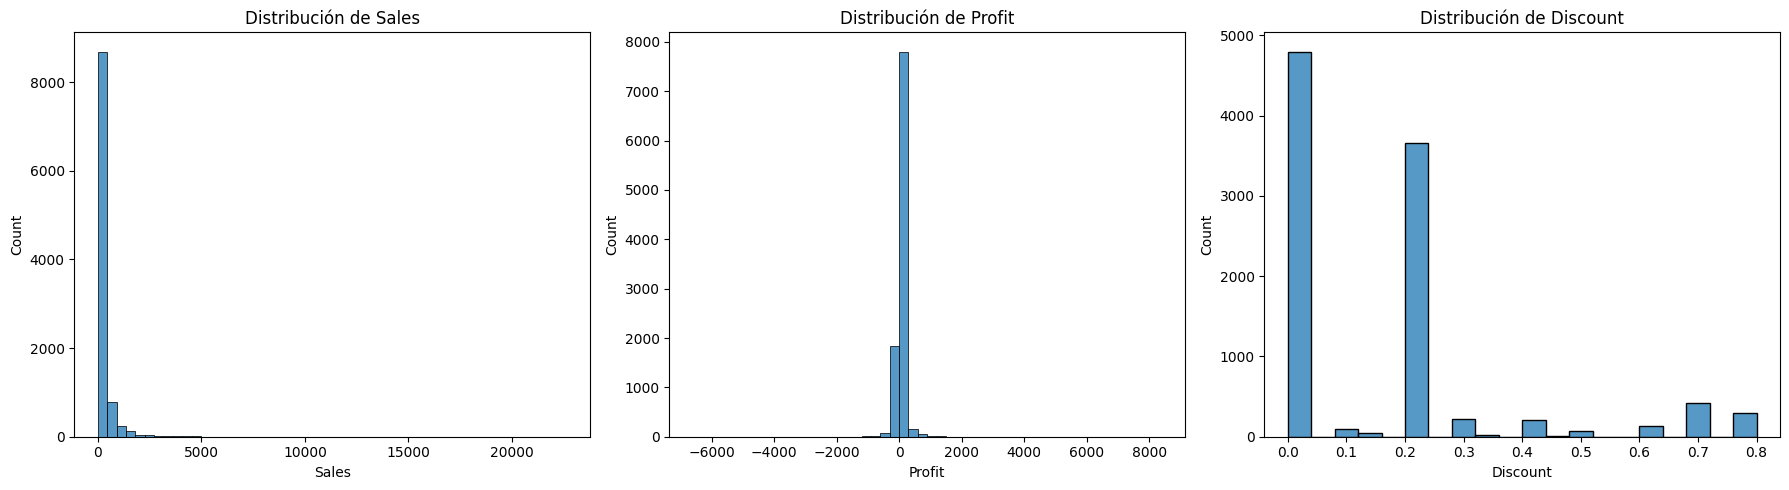

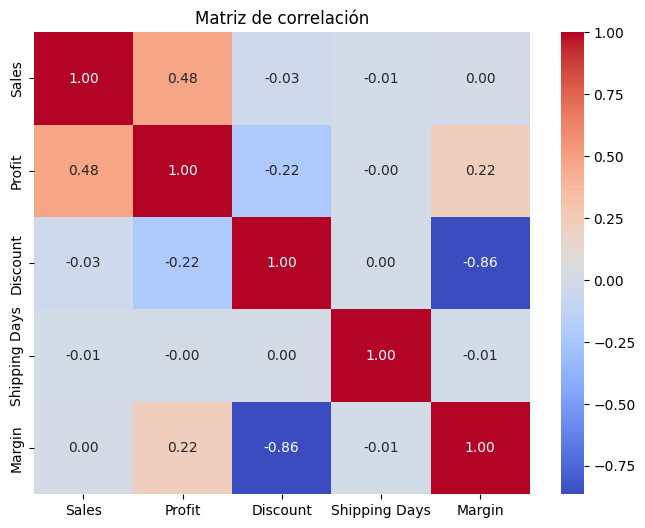

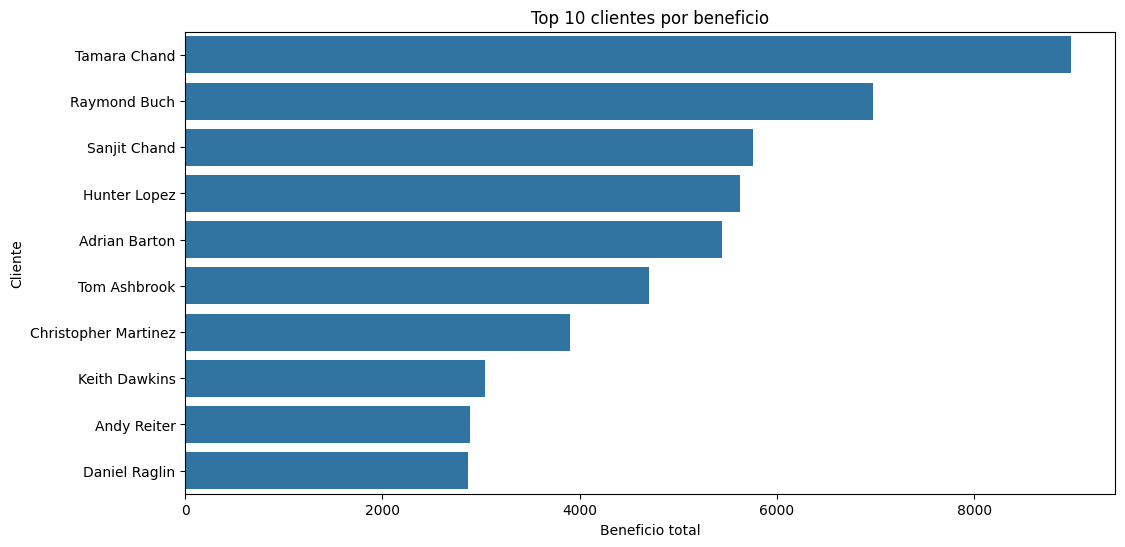

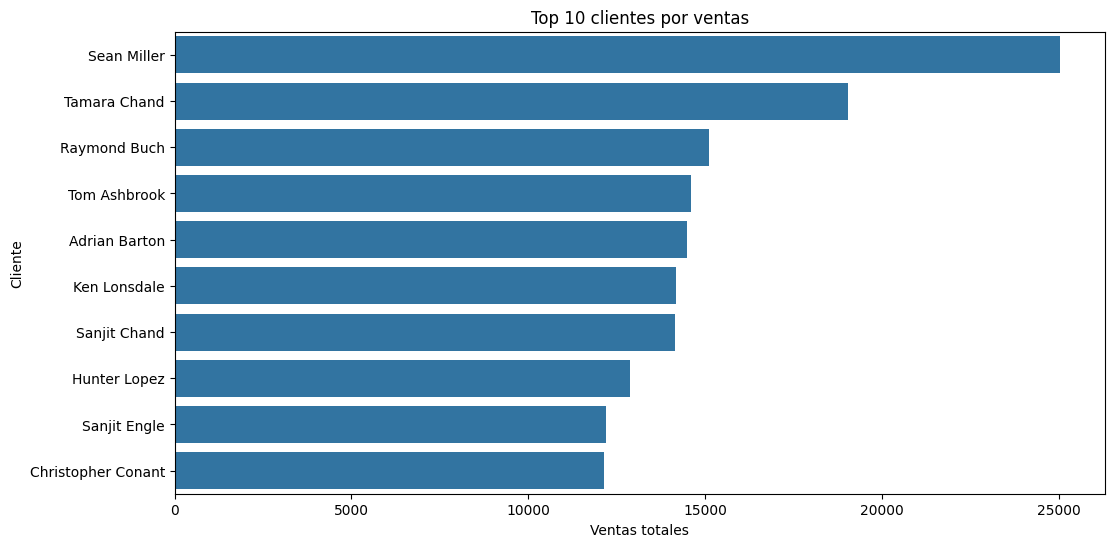

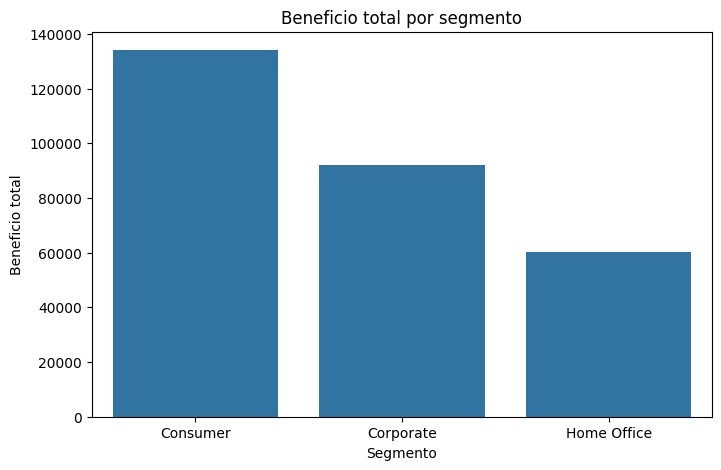

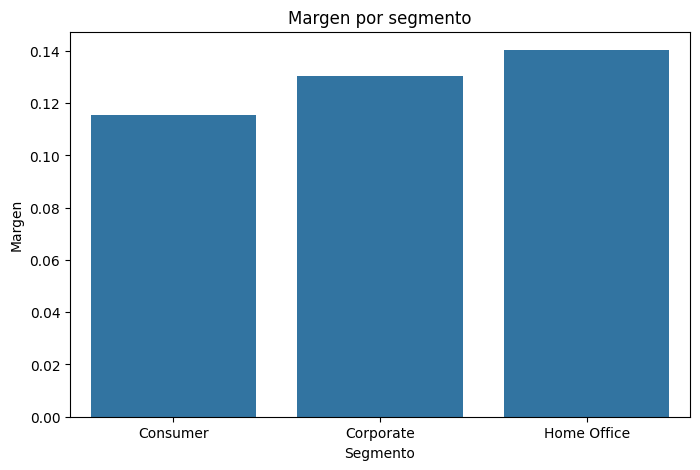

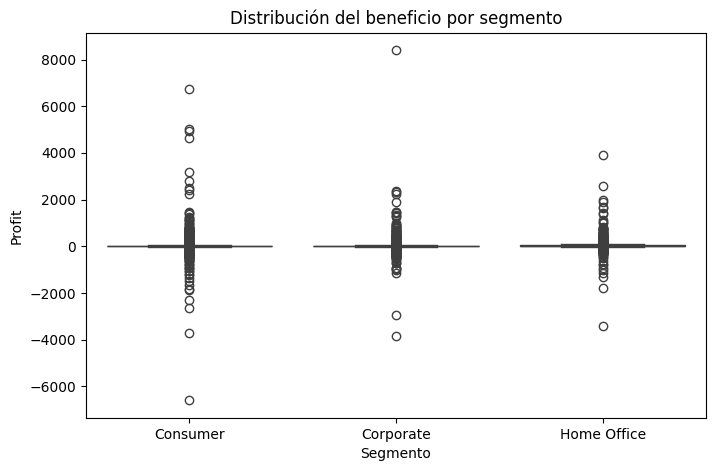

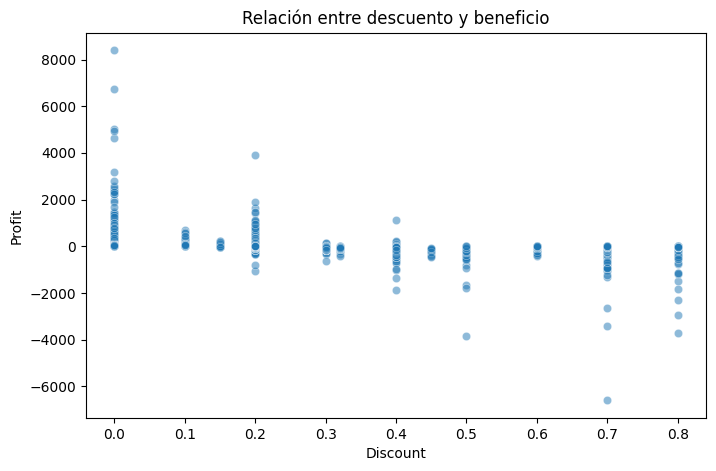

In [17]:
# Desarrolla tu código de EDA y preparación de datos

# Descripción del dataset y justificación de su elección
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

print("\nResumen estadístico:")
display(df.describe(include='all'))

# Identificación de variables, tipos, nulos y duplicados
print("\nTipos de variables:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isnull().sum())

print("\nNúmero de duplicados:", df.duplicated().sum())

cat_vars = df.select_dtypes(include='object').columns.tolist()
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables categóricas:", cat_vars)
print("Variables numéricas:", num_vars)

# Limpieza de datos
# Copia de trabajo
df_clean = df.copy()

# Estandarizar nombres de columnas
df_clean.columns = df_clean.columns.str.strip()

# Convertir fechas
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], errors='coerce')
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'], errors='coerce')

# Eliminar duplicados
df_clean = df_clean.drop_duplicates()

# Revisar nulos tras conversión
print(df_clean.isnull().sum())

# Eliminar filas con nulos solo en variables críticas si existieran
df_clean = df_clean.dropna(subset=['Customer Name', 'Segment', 'Sales', 'Profit', 'Discount'])

print("Dimensiones tras limpieza:", df_clean.shape)

# Comprobar ventas iguales o menores que 0
print("Ventas <= 0:", (df_clean['Sales'] <= 0).sum())

# Comprobar descuentos fuera de rango esperable
print("Descuentos < 0:", (df_clean['Discount'] < 0).sum())
print("Descuentos > 1:", (df_clean['Discount'] > 1).sum())

# Creación de nuevas variables (feature engineering)
# Margen porcentual
df_clean['Margin'] = np.where(df_clean['Sales'] != 0,
                              df_clean['Profit'] / df_clean['Sales'],
                              np.nan)

# Pedido con pérdidas
df_clean['Loss Order'] = (df_clean['Profit'] < 0).astype(int)

# Pedido con descuento alto
df_clean['High Discount'] = (df_clean['Discount'] > 0.2).astype(int)

# Tiempo de envío
df_clean['Shipping Days'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days

# Año y mes del pedido
df_clean['Order Year'] = df_clean['Order Date'].dt.year
df_clean['Order Month'] = df_clean['Order Date'].dt.month

#Tablas agregadas para clientes y segmentos
#Rentabilidad por cliente
customer_profit = (
    df_clean
    .groupby('Customer Name')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_Discount=('Discount', 'mean'),
        Num_Orders=('Order ID', 'nunique'),
        Loss_Orders=('Loss Order', 'sum')
    )
    .reset_index()
)

customer_profit['Margin'] = np.where(
    customer_profit['Total_Sales'] != 0,
    customer_profit['Total_Profit'] / customer_profit['Total_Sales'],
    np.nan
)

customer_profit = customer_profit.sort_values(by='Total_Profit', ascending=False)

customer_profit.head()

#Rentabilidad por segmento
segment_profit = (
    df_clean
    .groupby('Segment')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Avg_Discount=('Discount', 'mean'),
        Num_Orders=('Order ID', 'nunique'),
        Loss_Orders=('Loss Order', 'sum')
    )
    .reset_index()
)

segment_profit['Margin'] = np.where(
    segment_profit['Total_Sales'] != 0,
    segment_profit['Total_Profit'] / segment_profit['Total_Sales'],
    np.nan
)

segment_profit = segment_profit.sort_values(by='Total_Profit', ascending=False)

segment_profit

# Transformaciones: encoding y escalado
df_model = df_clean.copy()

df_model = pd.get_dummies(df_model, columns=['Segment', 'Region', 'Category', 'Ship Mode'], drop_first=True)

df_model.head()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['Sales', 'Profit', 'Discount', 'Shipping Days']
df_model[cols_to_scale] = scaler.fit_transform(df_model[cols_to_scale])

df_model[cols_to_scale].head()

# Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
#Distribuciones de ventas, profit y discount
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean['Sales'], bins=50, ax=axes[0])
axes[0].set_title('Distribución de Sales')

sns.histplot(df_clean['Profit'], bins=50, ax=axes[1])
axes[1].set_title('Distribución de Profit')

sns.histplot(df_clean['Discount'], bins=20, ax=axes[2])
axes[2].set_title('Distribución de Discount')

plt.tight_layout()
plt.show()

#Correlaciones entre variables numéricas
plt.figure(figsize=(8, 6))
corr = df_clean[['Sales', 'Profit', 'Discount', 'Shipping Days', 'Margin']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

#Top 10 clientes por beneficio
top10_customers = customer_profit.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_customers, x='Total_Profit', y='Customer Name')
plt.title('Top 10 clientes por beneficio')
plt.xlabel('Beneficio total')
plt.ylabel('Cliente')
plt.show()

#Top 10 clientes por ventas
top10_sales_customers = customer_profit.sort_values(by='Total_Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_sales_customers, x='Total_Sales', y='Customer Name')
plt.title('Top 10 clientes por ventas')
plt.xlabel('Ventas totales')
plt.ylabel('Cliente')
plt.show()

#Beneficio por segmento
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_profit, x='Segment', y='Total_Profit')
plt.title('Beneficio total por segmento')
plt.xlabel('Segmento')
plt.ylabel('Beneficio total')
plt.show()

#Margen por segmento
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_profit, x='Segment', y='Margin')
plt.title('Margen por segmento')
plt.xlabel('Segmento')
plt.ylabel('Margen')
plt.show()

#Boxplot de profit por segmento
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Segment', y='Profit')
plt.title('Distribución del beneficio por segmento')
plt.xlabel('Segmento')
plt.ylabel('Profit')
plt.show()

#Descuento vs beneficio
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Discount', y='Profit', alpha=0.5)
plt.title('Relación entre descuento y beneficio')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

# Explicaciones y decisiones en función de los resultados (punto de vista de negocio)

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué


In [ ]:
# Desarrolla tu código de Clasificación

## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

In [ ]:
# Desarrolla tu código de Regresión

## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

In [ ]:
# Desarrolla tu código de PCA y No Supervisados

----

## 🔒 FASE 2 — Se desbloquea en Semana 2 (solo entonces editar esta parte)


## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**  
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**  
Regresión: Predicción del profit

**Vía 3::**  
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

In [ ]:
# Qué modelo creeis que funcionará mejor con estos datos y porqué.
# ---

**✍️ Si no tienes claro que modelo es el mejor, saltate este apartado y completalo al final de la sesión.:**

*(Vamos a hacer una propuesta interesante, vamos a probar diferentes modelos para decirdir con criterio)*

---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [ ]:
#Pistas, recuerda tener cargadas todas las librerias
#!pip install xgboost shap --quiet

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mtick
#import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

#from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
#from sklearn.ensemble import RandomForestRegressor

#from xgboost import XGBRegressor

#import shap
#shap.initjs()

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------


#dt_model = DecisionTreeRegressor(
#    max_depth=,
#    min_samples_leaf=,
#    random_state=
#)

#dt_model.fit(X_train, y_train)

#dt_preds = dt_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

#rf_model = RandomForestRegressor(
#    n_estimators=...,
#    max_depth=....,
#    max_features=...,
#    n_jobs=....,
#    random_state=....
#)

#rf_model.fit(X_train, y_train)

#rf_preds = rf_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — XGBoost Regressor
# -------------------------------------------------------


#xgb_model = XGBRegressor(
#    n_estimators=....,
#    max_depth=...,
#    learning_rate=...,
#    subsample=....,
#    colsample_bytree=...,
#    reg_alpha=....,
#    reg_lambda=...,
#    random_state=...,
#    verbosity=....
#)

#xgb_model.fit(X_train, y_train)

#xgb_preds = xgb_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [ ]:
# -------------------------------------------------------
# FINE-TUNING — GridSearchCV sobre XGBoost (Ejemplo sobre XGBoost, si has elegido otro, hazlo sobre tu elección)
# -------------------------------------------------------


#param_grid = {
#    'n_estimators'    : [200, 400],
#    'max_depth'       : [4, 6],
#    'learning_rate'   : [0.05, 0.1],
#    'subsample'       : [0.7, 0.9],
#    'colsample_bytree': [0.7, 1.0],
#}

#xgb_base = XGBRegressor(random_state=42, verbosity=0)

#grid_search = GridSearchCV(
#    estimator=xgb_base,
#    param_grid=param_grid,
#    scoring='neg_root_mean_squared_error',
#    cv=....,
#    n_jobs=.....,
#    verbose=....
#)

#grid_search.fit(X_train, y_train)

---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 1 — Summary Plot (visión global)
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 2 — Waterfall: explicamos UN pedido concreto
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 3 — Dependence Plot: efecto del Discount
# -------------------------------------------------------

**✍️ Reflexión SHAP (SOLUCIÓN):**

1. **Top 3 variables según SHAP:** .... Rellenar...

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio

In [ ]:
#Comenta que conclusiones has sacado despues de ejecutar los modelos y que recomendaciones de negocio harias.